Loads the results CSV into a DataFrame and prints the number of cities.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/reference/results.csv')
print(len(df))


80


In [51]:

import duckdb


coords = duckdb.sql("""
SELECT replace(parse_filename(filename,true),'.csv','') AS city_slug,
       MEDIAN(latitude) AS lat, MEDIAN(longitude) AS lon
FROM read_csv_auto('../data/*.csv', filename=true, union_by_name=true)
GROUP BY 1
""").df()

df = df.merge(coords, on="city_slug", how="left")
print(df[["city","lat","lon"]].head())

          city        lat         lon
0      Chicago  41.894645  -87.656307
1    Edinburgh  55.950649   -3.193480
2     Portland  45.526249 -122.654165
3     Columbus  39.980720  -82.996920
4  Minneapolis  44.961350  -93.264816


Plots annual revenue against city-centre ROI as a scatter plot, annotating the extreme points, and saves it as revenue_vs_roi.png.

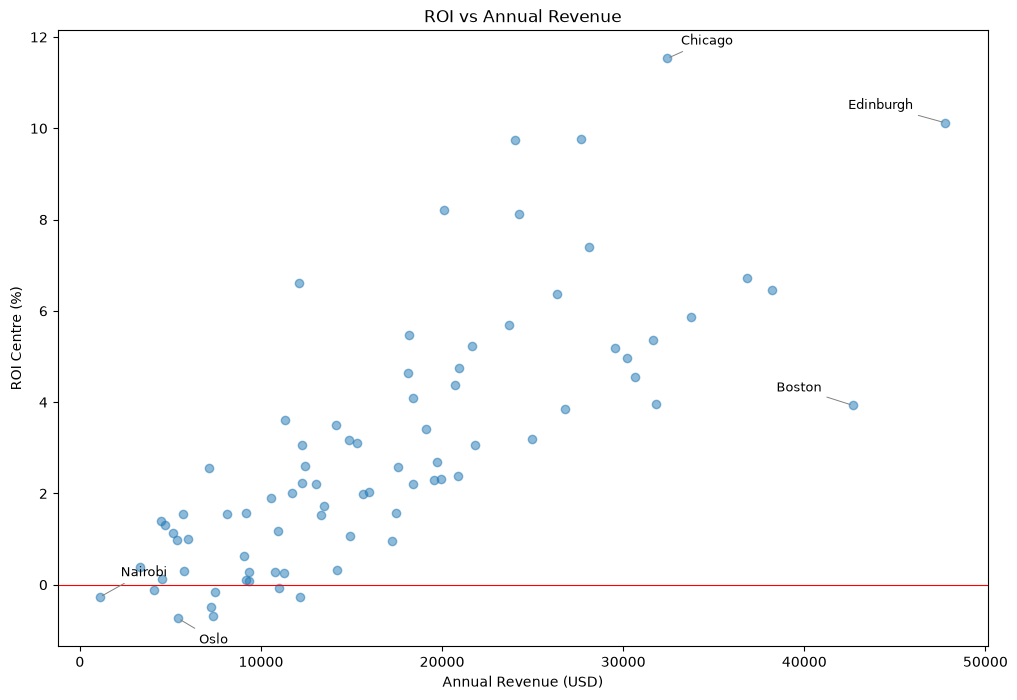

In [14]:
x=df['annual_revenue_usd']
y= df['roi_centre']

fig, ax= plt.subplots(figsize=(12,8))

ax.scatter(x,y, alpha=0.5)
ax.set_xlabel('Annual Revenue (USD)')
ax.set_ylabel('ROI Centre (%)')
ax.set_title ('ROI vs Annual Revenue')
ax.axhline(0, color='r', linewidth=0.8)

picks= pd.concat([df.nlargest(1,'annual_revenue_usd'), df.nlargest(1,'roi_centre'), df.nsmallest(1,'annual_revenue_usd'), df.nsmallest(1,'roi_centre')])

offsets = {
    "Chicago":   (10, 10),
    "Edinburgh": (-70, 10),
    "Boston":    (-55, 10),
    "Nairobi":   (15, 15),
    "Oslo":      (15, -18),
}
for city, off in offsets.items():
    r = df[df["city"] == city].iloc[0]
    ax.annotate(city, (r["annual_revenue_usd"], r["roi_centre"]),
                xytext=off, textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="-", lw=0.7, color="grey"))
plt.savefig('../charts/revenue_vs_roi.png', dpi=150, bbox_inches='tight')
plt.show()
    

Computes the correlation between annual revenue and city-centre ROI.

In [3]:
df["annual_revenue_usd"].corr(df["roi_centre"])

np.float64(0.7715156619641029)

Computes the correlation between property price per m² and city-centre ROI.

In [4]:
df['price_sqm_centre'].corr(df['roi_centre'])

np.float64(-0.36116345612902995)

Plots the ROI range (centre vs. outside) for the top 20 cities by ROI and saves it as roi_range.png.

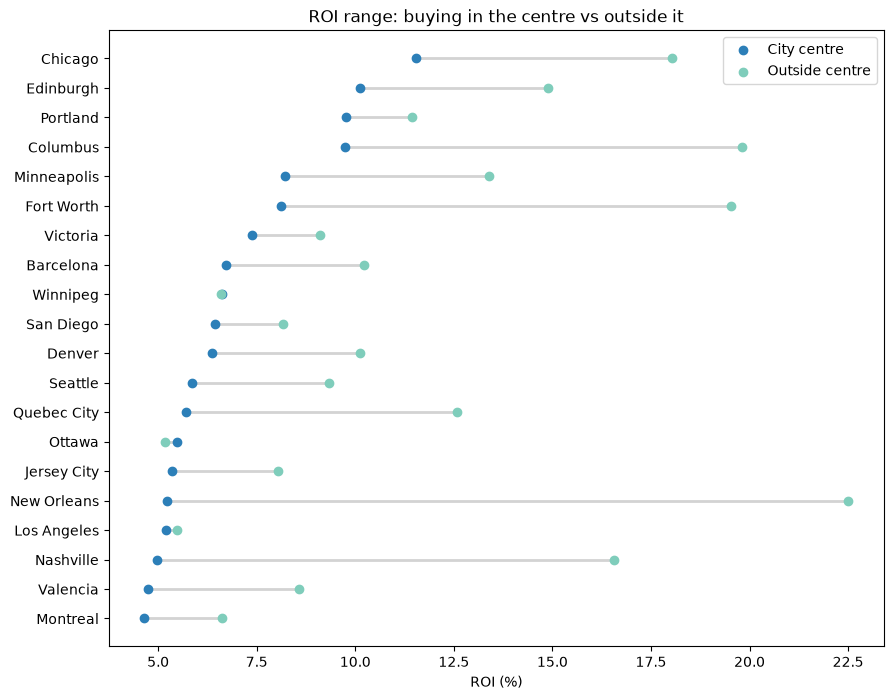

In [5]:
top = df.nlargest(20, 'roi_centre').sort_values('roi_centre')

fig, ax = plt.subplots(figsize=(10, 8))

ax.hlines(y=top['city'], xmin=top['roi_centre'], xmax=top['roi_outside'],
          color='lightgrey', linewidth=2)
ax.scatter(top['roi_centre'], top['city'], color='#2c7fb8', label='City centre', zorder=3)
ax.scatter(top['roi_outside'], top['city'], color='#7fcdbb', label='Outside centre', zorder=3)

ax.set_xlabel('ROI (%)')
ax.set_title('ROI range: buying in the centre vs outside it')
ax.legend()

plt.savefig('../charts/roi_range.png', dpi=150, bbox_inches='tight')
plt.show()

Computes the ROI spread (outside minus centre) per city and lists the 50 cities with the largest spread.

In [6]:
df["spread"] = df["roi_outside"] - df["roi_centre"]
df.nlargest(50, "spread")[["city", "country", "roi_centre", "roi_outside", "spread"]]

,city,country,roi_centre,roi_outside,spread
15,New Orleans,United States,5.23,22.51,17.28
17,Nashville,United States,4.96,16.55,11.59
5,Fort Worth,United States,8.12,19.52,11.40
3,Columbus,United States,9.74,19.80,10.06
25,Washington,United States,3.85,11.84,7.99
12,Quebec City,Canada,5.70,12.57,6.87
38,Dallas,United States,2.39,9.04,6.65
0,Chicago,United States,11.53,18.03,6.50
24,Boston,United States,3.93,9.44,5.51
32,Seville (Sevilla),Spain,3.07,8.27,5.20


Shows the average ROI spread by country, sorted descending.

In [7]:
df.groupby('country')['spread'].mean().sort_values(ascending=False)

country
United States        5.097143
Mexico               3.970000
Spain                3.750000
Turkey               3.000000
Belgium              2.733333
Italy                2.305000
Ireland              2.260000
Brazil               1.840000
Canada               1.828571
United Kingdom       1.705000
Portugal             1.660000
Japan                1.510000
Hungary              1.370000
Austria              1.290000
South Africa         1.180000
Australia            1.026667
Sweden               0.960000
France               0.900000
Argentina            0.880000
Taiwan               0.760000
Germany              0.760000
Thailand             0.750000
Netherlands          0.690000
Czech Republic       0.680000
Latvia               0.650000
Kenya                0.440000
Greece               0.425000
Colombia             0.390000
Denmark              0.330000
Hong Kong (China)    0.200000
Norway               0.180000
Chile                0.100000
Name: spread, dtype: float64

Generates a pairplot of ROI, revenue, price per m², nights booked, and nightly price, saved as pairplot.png.

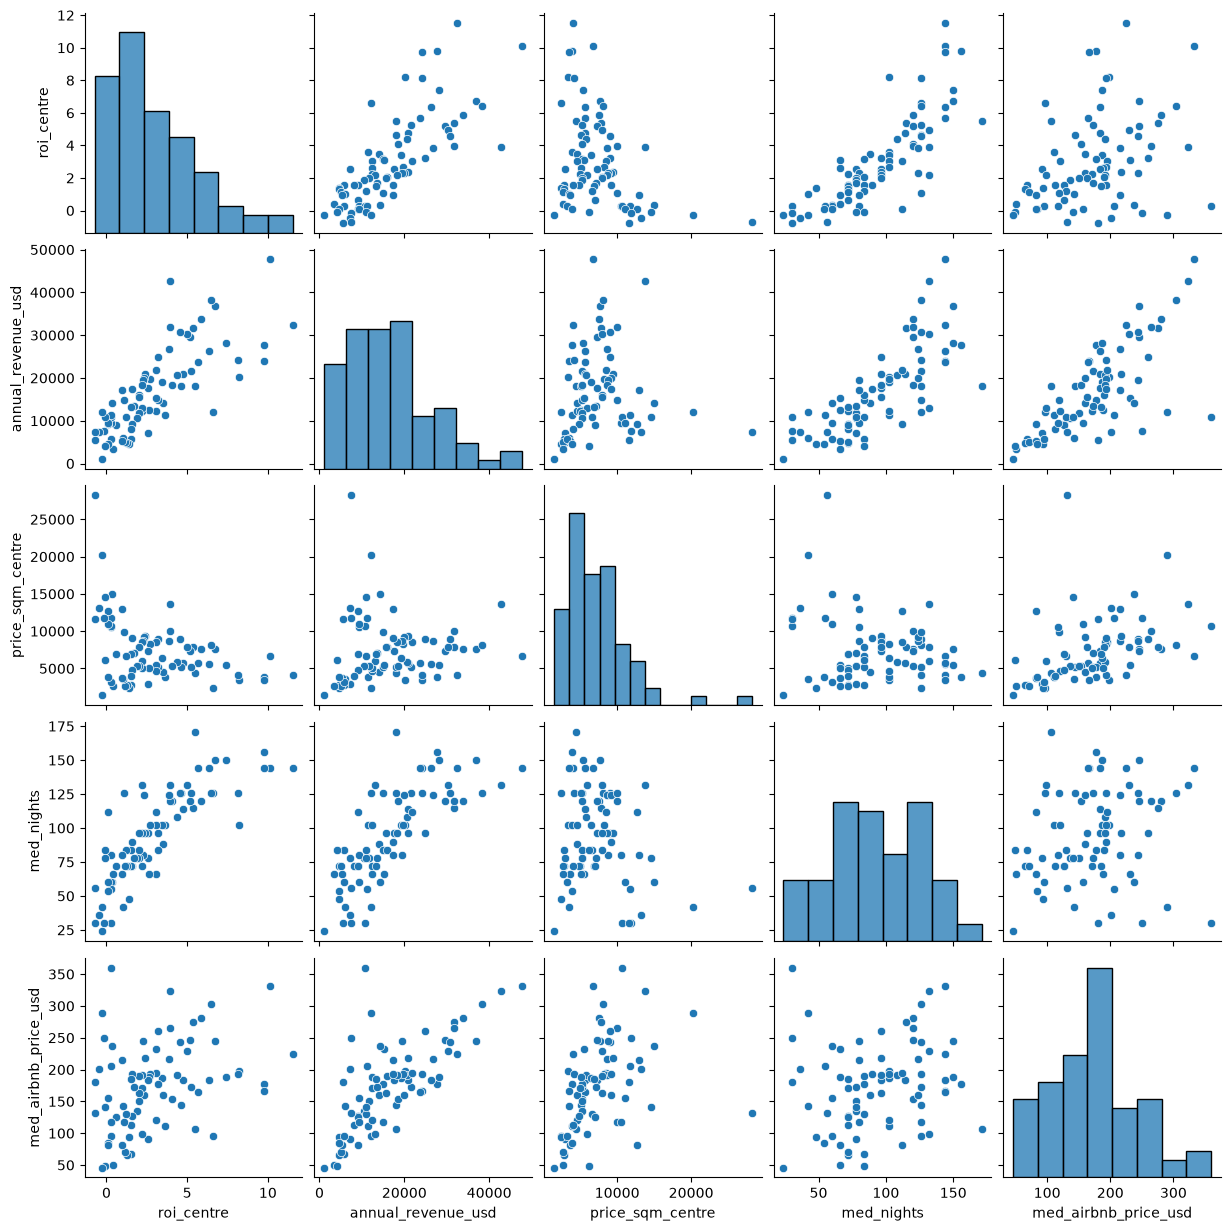

In [8]:
g = sns.pairplot(df[["roi_centre","annual_revenue_usd","price_sqm_centre","med_nights","med_airbnb_price_usd"]])
g.savefig('../charts/pairplot.png', dpi=150, bbox_inches='tight')

Prints correlations of occupancy, revenue, and nightly price against ROI.

In [9]:
print("occupancy vs roi:", round(df["med_nights"].corr(df["roi_centre"]),3))
print("revenue vs roi:  ", round(df["annual_revenue_usd"].corr(df["roi_centre"]),3))
print("nightly vs roi:  ", round(df["med_airbnb_price_usd"].corr(df["roi_centre"]),3))

occupancy vs roi: 0.81
revenue vs roi:   0.772
nightly vs roi:   0.356


Prints correlations between nights booked, nightly price, and property price.

In [10]:
print("nights vs property price: ", round(df["med_nights"].corr(df["price_sqm_centre"]),3))
print("nightly vs property price:", round(df["med_airbnb_price_usd"].corr(df["price_sqm_centre"]),3))

nights vs property price:  -0.203
nightly vs property price: 0.409


Estimates the revenue-vs-price share of ROI variation using log-variance decomposition.

In [11]:
import numpy as np
lr = np.log(df["annual_revenue_usd"]); lm = np.log(df["price_sqm_centre"])
print("var log revenue:", round(lr.var(),3), "| var log price:", round(lm.var(),3))
print("log corr:", round(lr.corr(lm),3))
print("revenue share:", round(lr.var()/(lr.var()+lm.var()),3))

var log revenue: 0.461 | var log price: 0.286
log corr: 0.358
revenue share: 0.617


Shows the top 3 cities by nights booked, with their price and ROI.

In [12]:
df.nlargest(3, "med_nights")[["city","country","med_nights","price_sqm_centre","roi_centre"]]

,city,country,med_nights,price_sqm_centre,roi_centre
13,Ottawa,Canada,171.0,4368.09,5.47
2,Portland,United States,156.0,3896.40,9.77
6,Victoria,Canada,150.0,5407.17,7.39


Plots property price vs. nights booked colored by ROI, annotating selected cities, and saves it as drivers.png.

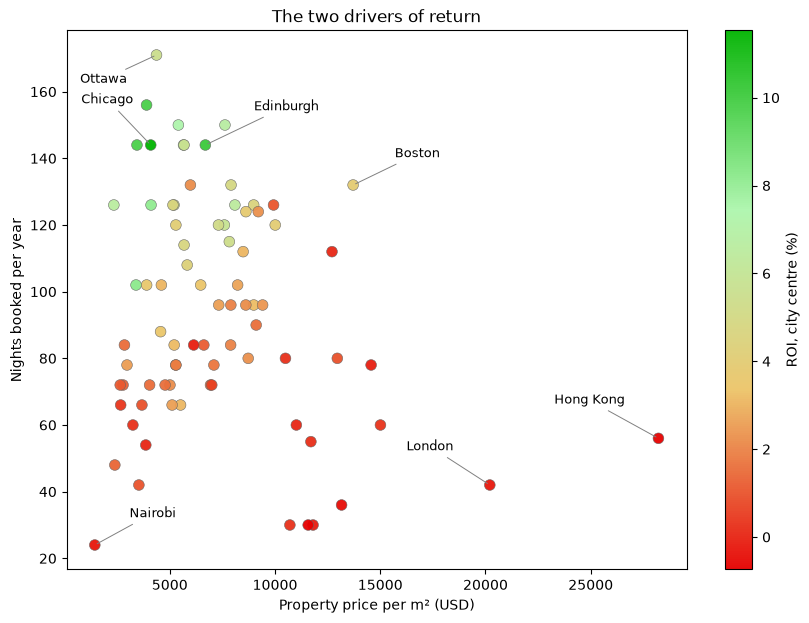

In [47]:
from matplotlib.colors import LinearSegmentedColormap
redgreen = LinearSegmentedColormap.from_list("redgreen", ["#e60000", "#ecc468", "#adf6ad85", "#00b300"])

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df["price_sqm_centre"], df["med_nights"],
                c=df["roi_centre"], cmap=redgreen, s=60, alpha=0.95,
                edgecolors="#666666", linewidths=0.4)
fig.colorbar(sc, ax=ax, label="ROI, city centre (%)")

ax.set_xlabel("Property price per m² (USD)")
ax.set_ylabel("Nights booked per year")
ax.set_title("The two drivers of return")

offsets = {
    "Hong Kong": (-75, 25),
    "London":    (-60, 25),
    "Boston":    (30, 20),
    "Chicago":   (-50, 30),
    "Edinburgh": (35, 25),
    "Ottawa":    (-55, -20),
    "Nairobi":   (25, 20),
}

for city, off in offsets.items():
    r = df[df["city"] == city].iloc[0]
    ax.annotate(city, (r["price_sqm_centre"], r["med_nights"]),
                xytext=off, textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="-", lw=0.7, color="grey"))

plt.savefig('../charts/drivers.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
for col in ["med_nights","annual_revenue_usd","price_sqm_centre","med_airbnb_price_usd"]:
    print(f"{col:<24} centre {df[col].corr(df['roi_centre']):+.3f}   outside {df[col].corr(df['roi_outside']):+.3f}")
print()
print("top by roi_outside:")
print(df.nlargest(3,"roi_outside")[["city","country","roi_centre","roi_outside"]].to_string())

med_nights               centre +0.810   outside +0.716
annual_revenue_usd       centre +0.772   outside +0.686
price_sqm_centre         centre -0.361   outside -0.289
med_airbnb_price_usd     centre +0.356   outside +0.317

top by roi_outside:
           city        country  roi_centre  roi_outside
15  New Orleans  United States        5.23        22.51
3      Columbus  United States        9.74        19.80
5    Fort Worth  United States        8.12        19.52


In [32]:
# Ratio of outside-centre to centre property price — cited in Limitations
df["price_ratio"] = (df["price_sqm_out"] / df["price_sqm_centre"]).round(2)
df.nsmallest(10, "price_ratio")[["city", "country", "price_ratio"]]

,city,country,price_ratio
15,New Orleans,United States,0.27
17,Nashville,United States,0.34
38,Dallas,United States,0.34
25,Washington,United States,0.38
42,Rome,Italy,0.39
60,Rio de Janeiro,Brazil,0.41
72,Vienna,Austria,0.42
75,London,United Kingdom,0.42
5,Fort Worth,United States,0.44
32,Seville (Sevilla),Spain,0.44


In [35]:
# Twenty cheapest property markets, centre — cited in Findings
display(df.nsmallest(20, "price_sqm_centre")[["city","country","price_sqm_centre","med_nights","roi_centre"]])


,city,country,price_sqm_centre,med_nights,roi_centre
76,Nairobi,Kenya,1436.47,24.0,-0.27
8,Winnipeg,Canada,2341.75,126.0,6.61
54,Cape Town,South Africa,2388.51,48.0,1.39
57,Buenos Aires,Argentina,2644.00,72.0,1.13
63,Bogota,Colombia,2665.91,66.0,0.38
55,Sao Paulo,Brazil,2777.60,72.0,1.30
52,Santiago,Chile,2845.32,84.0,1.54
37,Istanbul,Turkey,2967.01,78.0,2.56
65,Riga,Latvia,3245.83,60.0,0.29
4,Minneapolis,United States,3395.59,102.0,8.22


In [34]:
# Twenty cheapest property markets, outside — cited in Findings
display(df.nsmallest(20, "price_sqm_out")[["city","country","price_sqm_out","med_nights","roi_outside"]])

,city,country,price_sqm_out,med_nights,roi_outside
76,Nairobi,Kenya,900.34,24.0,0.17
15,New Orleans,United States,1379.00,126.0,22.51
60,Rio de Janeiro,Brazil,1508.01,66.0,3.80
54,Cape Town,South Africa,1594.66,48.0,2.57
37,Istanbul,Turkey,1611.53,78.0,5.56
3,Columbus,United States,1775.50,144.0,19.80
5,Fort Worth,United States,1825.63,126.0,19.52
57,Buenos Aires,Argentina,1871.33,72.0,2.01
32,Seville (Sevilla),Spain,2017.24,102.0,8.27
55,Sao Paulo,Brazil,2024.68,72.0,2.15


In [36]:
# Rank-sum cross-check: cheapest property + highest revenue — cited in Findings
df["rank_cheap"] = df["price_sqm_centre"].rank()
df["rank_rev"] = df["annual_revenue_usd"].rank(ascending=False)
df["combined_rev"] = df["rank_cheap"] + df["rank_rev"]
df.nsmallest(10, "combined_rev")[["city","country","price_sqm_centre","annual_revenue_usd","roi_centre","combined_rev"]]

,city,country,price_sqm_centre,annual_revenue_usd,roi_centre,combined_rev
0,Chicago,United States,4094.16,32426.0,11.53,24.0
2,Portland,United States,3896.40,27648.0,9.77,28.0
3,Columbus,United States,3440.00,24048.0,9.74,29.0
4,Minneapolis,United States,3395.59,20132.0,8.22,35.0
5,Fort Worth,United States,4109.17,24255.0,8.12,36.0
1,Edinburgh,United Kingdom,6689.03,47787.0,10.12,43.0
6,Victoria,Canada,5407.17,28137.0,7.39,44.0
15,New Orleans,United States,5200.75,21672.0,5.23,48.0
10,Denver,United States,5653.09,26352.0,6.37,49.0
13,Ottawa,Canada,4368.09,18146.0,5.47,52.0


In [40]:
low = df[df["med_nights"] < 100]
print("cities under 100 nights:", len(low), "| best ROI:", low["roi_centre"].max())
print(low.nlargest(3, "roi_centre")[["city","med_nights","price_sqm_centre","roi_centre"]])

cities under 100 nights: 45 | best ROI: 3.5
         city  med_nights  price_sqm_centre  roi_centre
27    Antwerp        88.0           4562.08        3.50
29     Dublin        96.0           8988.30        3.20
30  Las Vegas        84.0           5208.26        3.18


In [48]:
df.nlargest(3, "pct_capped")[["city","country","pct_capped","med_nights"]]

,city,country,pct_capped,med_nights
1,Edinburgh,United Kingdom,29.1,144.0
12,Quebec City,Canada,28.7,144.0
3,Columbus,United States,26.9,144.0


In [55]:
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

redgreen = LinearSegmentedColormap.from_list("redgreen", ["#e60000", "#ff8c42", "#8ed98e", "#00a300"])
VMIN, VMAX = -1, 12

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

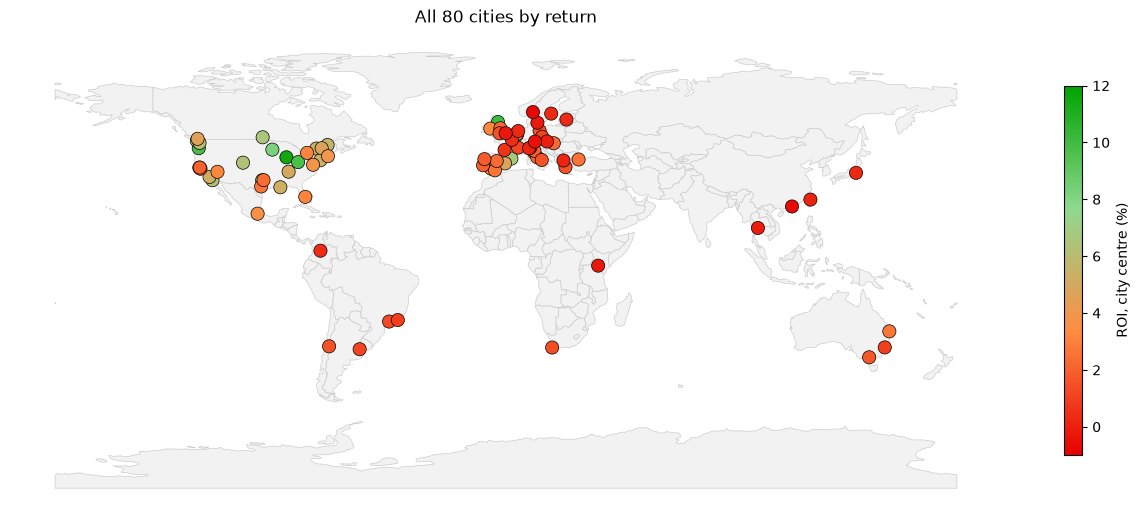

In [56]:
fig, ax = plt.subplots(figsize=(16, 8))
world.plot(ax=ax, color="#f2f2f2", edgecolor="#cccccc", linewidth=0.5)
sc = ax.scatter(df["lon"], df["lat"], c=df["roi_centre"], cmap=redgreen,
                vmin=VMIN, vmax=VMAX, s=90, edgecolors="black", linewidths=0.5, zorder=3)
fig.colorbar(sc, ax=ax, label="ROI, city centre (%)", shrink=0.6)
ax.set_title("All 80 cities by return")
ax.set_axis_off()
plt.savefig('../charts/map_all.png', dpi=150, bbox_inches='tight')
plt.show()

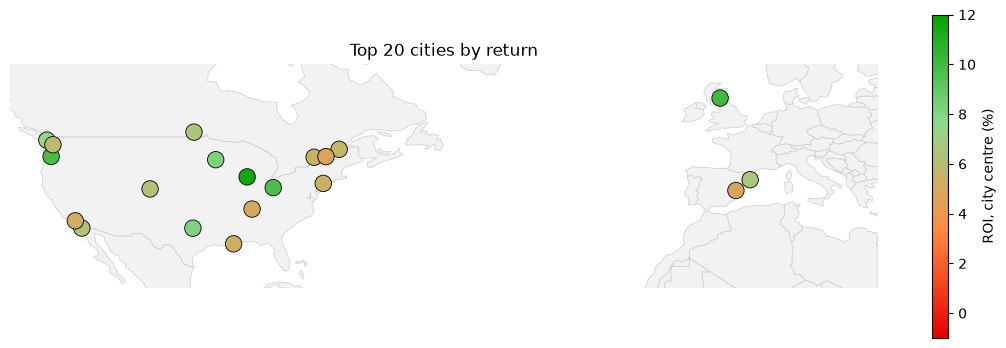

In [57]:
top = df.nlargest(20, "roi_centre")
fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color="#f2f2f2", edgecolor="#cccccc", linewidth=0.5)
sc = ax.scatter(top["lon"], top["lat"], c=top["roi_centre"], cmap=redgreen,
                vmin=VMIN, vmax=VMAX, s=140, edgecolors="black", linewidths=0.6, zorder=3)
fig.colorbar(sc, ax=ax, label="ROI, city centre (%)", shrink=0.6)
ax.set_xlim(-130, 25); ax.set_ylim(22, 62)
ax.set_title("Top 20 cities by return")
ax.set_axis_off()
plt.savefig('../charts/map_top20.png', dpi=150, bbox_inches='tight')
plt.show()

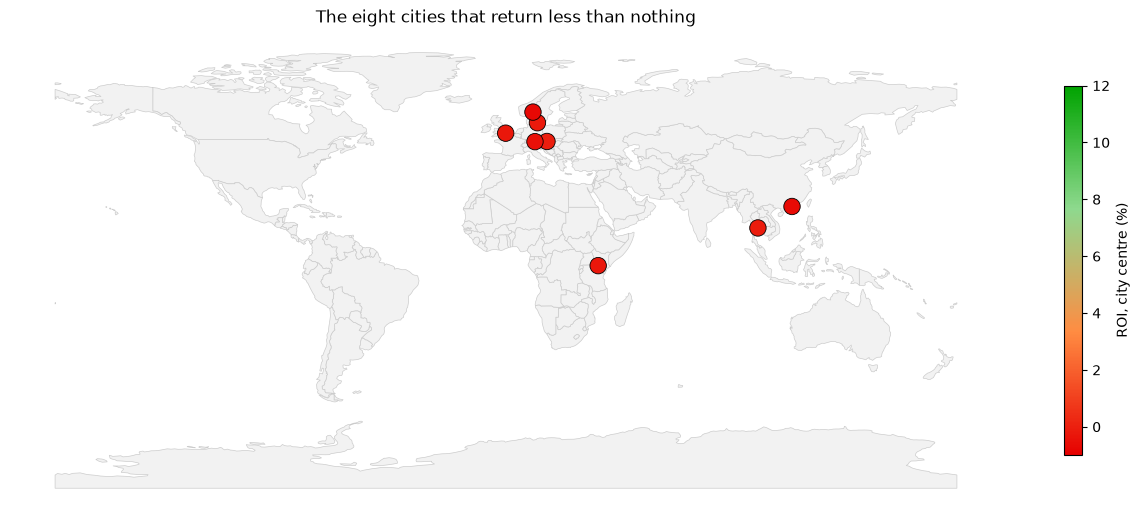

In [58]:
neg = df[df["roi_centre"] < 0]
fig, ax = plt.subplots(figsize=(16, 8))
world.plot(ax=ax, color="#f2f2f2", edgecolor="#cccccc", linewidth=0.5)
sc = ax.scatter(neg["lon"], neg["lat"], c=neg["roi_centre"], cmap=redgreen,
                vmin=VMIN, vmax=VMAX, s=140, edgecolors="black", linewidths=0.6, zorder=3)
fig.colorbar(sc, ax=ax, label="ROI, city centre (%)", shrink=0.6)
ax.set_title("The eight cities that return less than nothing")
ax.set_axis_off()
plt.savefig('../charts/map_negative.png', dpi=150, bbox_inches='tight')
plt.show()